# System 9: $V(r) = -10e^{-r^2}+0.8755e^{-(r-3)^2/1.5^2}$, $s$-wave bound state, narrow $p$-wave resonance.
- Supports an $s$-wave bound state at $E_b=-2.40706272$.
- Supports a $p$-wave resonance at $E_r=0.81592338 - i0.04959887 $
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.030357$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.064960 \le \phi < 0.785$.
- By $r=10$, $V(r=10)\propto 10^{-10} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem
from src.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
system_num = 9

n_guess = 256
L_guess = 50.0
phi_guess = 0.5

real_res_guess = 0.81592338 - 1j*0.04959887 #   1.98415675-1.37683568j
real_bound_guess = -2.40706272 + 1j*0.0
real_telem_guess = 0.88767295 - 1j*0.076656155
real_rr_guess = 0.74496945 + 1j*0.37551095

V_0, R = 10.0, 1.0
r_b, w, V_b = 3.0, 1.5, 0.8755102
def gauss_barrier(r):
    att_gauss = -V_0 * np.exp(-r**2/R**2)
    extra_barr = V_b * np.exp(-(r-r_b)**2/w**2)
    return att_gauss + extra_barr

In [3]:
save_plots = True
plots_folder = get_plots_path() / f"system_{system_num}"
plots_folder.mkdir(exist_ok=True, parents=True)

In [4]:
sbound_system_guess = DVR(n_guess, L_guess, rotation_angle=0.0, potential=gauss_barrier, l=0)
pres_system_guess = DVR(n_guess, L_guess, rotation_angle=phi_guess, potential=gauss_barrier, l=1)

### Plot the good region of $\phi$

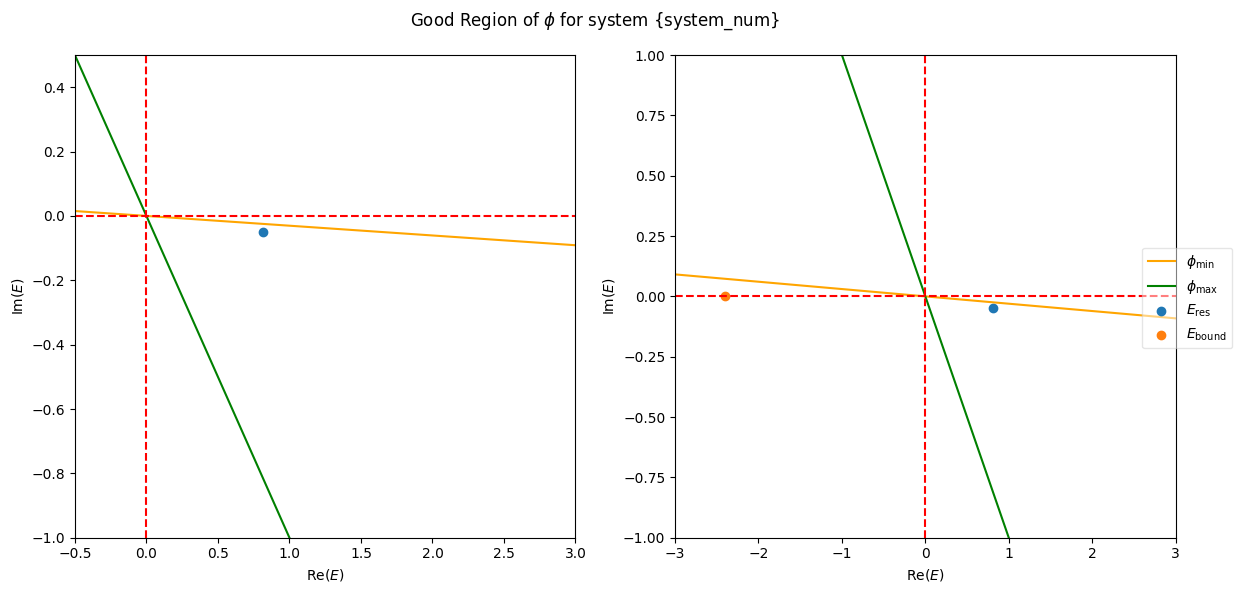

In [5]:
fig, (axres, axbound) = plt.subplots(1, 2, figsize=(12,6))
axres.set_xlim([-.5, 3.0])
axres.set_ylim([-1.0, 0.5])
axbound.set_xlim([-3.0, 3])
axbound.set_ylim([-1.0, 1.0])
for ax in (axres, axbound):
    ax.axline((0,0), (1, np.angle(real_res_guess)/2), color='orange', label=r'$\phi_\text{min}$')
    ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
    ax.axvline(0, linestyle='--', color='red')
    ax.axhline(0, linestyle='--', color='red')
    ax.scatter(np.real(real_res_guess), np.imag(real_res_guess), label=r'$E_\text{res}$')
    ax.set_xlabel(r"Re$(E)$")
    ax.set_ylabel(r"Im$(E)$")
    ax.legend().remove()
axbound.scatter(np.real(real_bound_guess), np.imag(real_bound_guess), label=r'$E_\text{bound}$')
fig.suptitle(r"Good Region of $\phi$ for system {system_num}")
handles, labels = axbound.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.95, 0.5), framealpha=0.5)
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "phi_good_region.png")
plt.show()

### Plot the spectrum for the $p$-wave resonance system

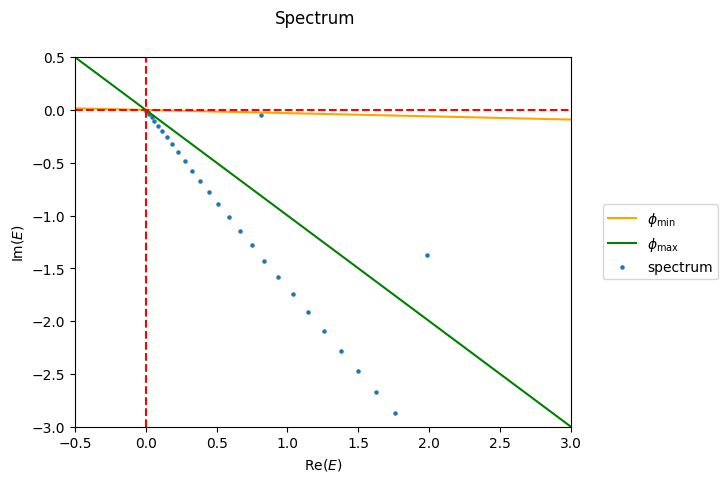

In [6]:
eigvals, _ = pres_system_guess.eig()
fig, ax = plt.subplots()
ax.axline((0,0), (1, np.angle(real_res_guess)/2), color='orange', label=r'$\phi_\text{min}$')
ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
ax.scatter(np.real(eigvals), np.imag(eigvals), label='spectrum', s=5)
ax.axvline(0, linestyle='--', color='red')
ax.axhline(0, linestyle='--', color='red')
ax.set_xlabel(r"Re$(E)$")
ax.set_ylabel(r"Im$(E)$")
ax.legend(loc='center left', bbox_to_anchor=[1.05, .5])
ax.set_xlim([-0.5, 3.0])
ax.set_ylim([-3., 0.5])
fig.suptitle(r"Spectrum")
plt.show()

### $E(L)$, $(r_\theta^2)(L)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $\phi$.

In [8]:
# compute <r^2> as L varies
mesh_width_guess = 0.2
observables = {
    "energy": obs_energy,
    "rr": obs_rr,
    "telem": obs_telem,
}
Ls = np.linspace(1.0, 75., 100)

results = scan_vs_L(
    phi_guess,
    real_res_guess,
    Ls,
    mesh_width=mesh_width_guess,
    observables=observables,
    resonance_potential=gauss_barrier,
    resonance_l=1,
    bound_energy=real_bound_guess,
    bound_potential=gauss_barrier,
    bound_l=0
)
energies_L = results["energy"]
rrs_L = results["rr"]
telems_L = results["telem"]
ns, drs = results["ns"], results["actual_mesh_widths"]
print(f"(min n, max n): ({np.min(ns)}, {np.max(ns)})")
print(f"Max difference from specific mesh width: {np.max(np.abs(drs-mesh_width_guess))}")

(min n, max n): (4, 374)
Max difference from specific mesh width: 0.007912457912457899


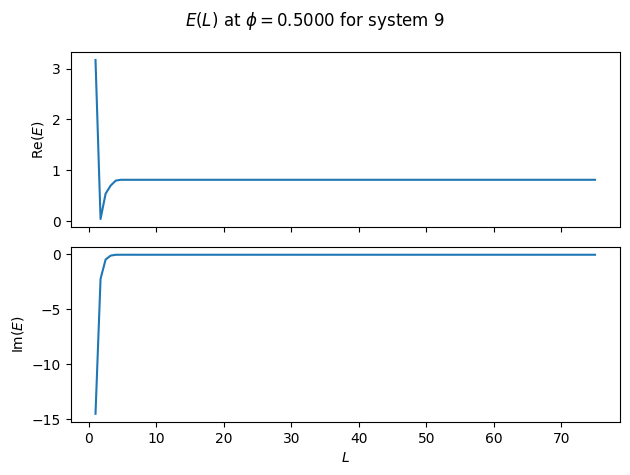

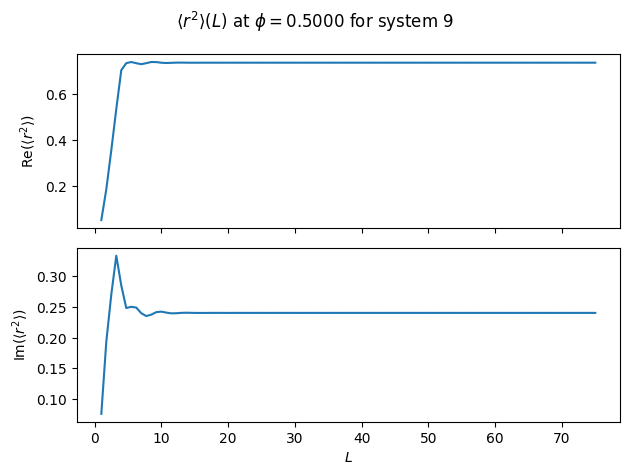

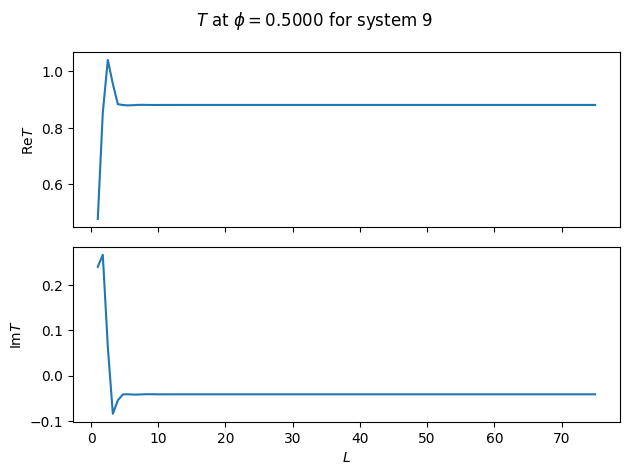

In [9]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies_L))
ax2.plot(Ls, np.imag(energies_L))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$E(L)$ at $\phi=${phi_guess:.4f} for system {system_num}")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_L")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs_L))
ax2.plot(Ls, np.imag(rrs_L))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$\langle r^2\rangle(L)$ at $\phi=${phi_guess:.4f} for system {system_num}")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_L.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(telems_L))
ax2.plot(Ls, np.imag(telems_L))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $\phi=${phi_guess:.4f} for system {system_num}")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_L.png")
plt.show()

### $E(\phi)$, $(r^2)(\theta)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $L$.

In [10]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phi_min_theoretical, phi_max_theoretical = get_phi_bounds(real_res_guess)
print(f"Theoretical good-phi range: ({phi_min_theoretical:.4f}, {phi_max_theoretical:.4f})")
phis = np.linspace(phi_min_theoretical, phi_max_theoretical, 100)
results = scan_vs_phi(
    pres_system_guess,
    real_res_guess,
    phis,
    observables,
    sbound_system_guess,
    real_bound_guess
)
energies_phi = results["energy"]
rrs_phi = results["rr"]
telems_phi = results["telem"]

Theoretical good-phi range: (0.0304, 0.7854)


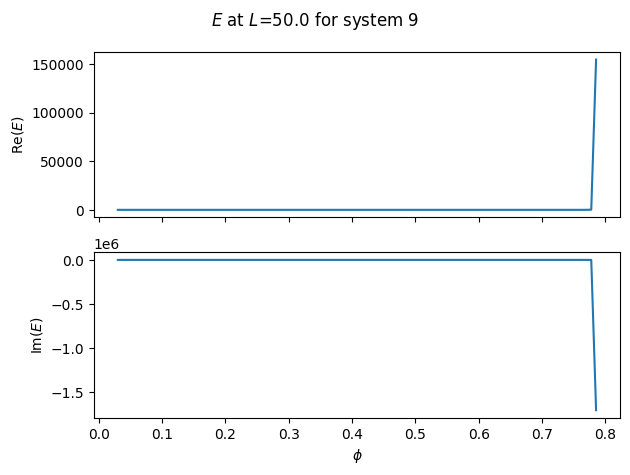

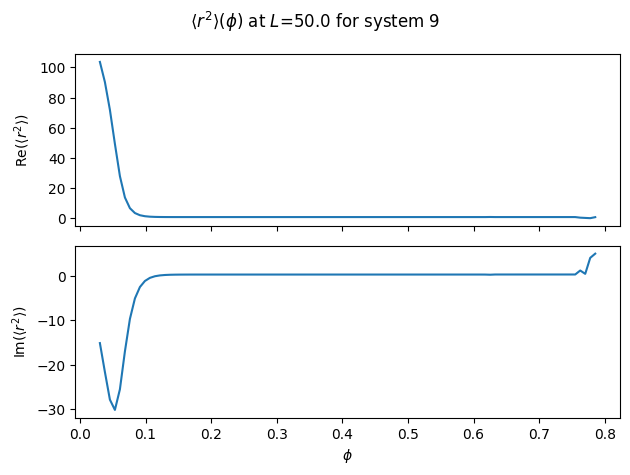

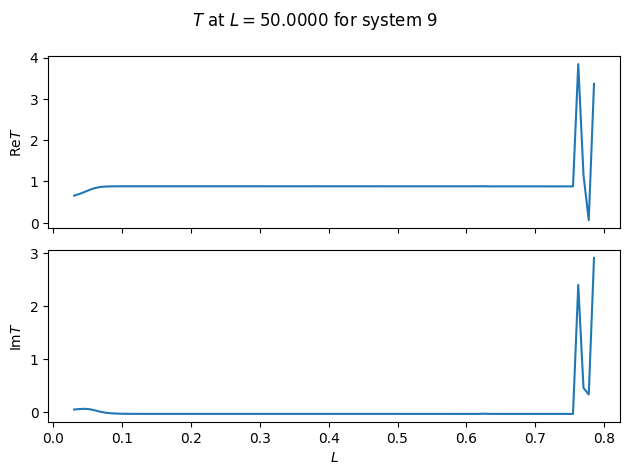

In [11]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies_phi))
ax2.plot(phis, np.imag(energies_phi))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(rf"$E$ at $L$={L_guess} for system {system_num}")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_phi.png")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs_phi))
ax2.plot(phis, np.imag(rrs_phi))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(rf"$\langle r^2\rangle(\phi)$ at $L$={L_guess} for system {system_num}")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_phi.png")
plt.show()

# plot transition matrix elements
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(telems_phi))
ax2.plot(phis, np.imag(telems_phi))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $L=${L_guess:.4f} for system {system_num}")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_phi.png")
plt.show()

### Using EC to predict $(r^2)$, $E$, and $(\psi_\text{res}|r|\psi_\text{bound})$.


In [13]:
# search for good (mesh_width, L) such that we converge as best as we can
# first, scan mesh widths for a few L to find the best match
L_test = np.array([20, 50, 75])
mesh_widths = np.linspace(0.1, 0.8, 30)
results = []
for L in L_test:
    result = search_mesh_width(
        gauss_barrier,
        real_res_guess,
        resonance_l=1,
        L=L,
        mesh_widths=mesh_widths,
        phi_lo=phi_min_theoretical,
        phi_hi=phi_max_theoretical,
        phi_scan=30,
        bound_potential=gauss_barrier,
        bound_energy=real_bound_guess,
        bound_l=0
    )
    results.append(result)

In [14]:
for L, result in zip(L_test, results):
    r = result[0]
    mesh_width, badness = r["mesh_width"], r["badness"]
    n, series = r["n"], r["series"]
    print(
        f"Best mesh width at L={L:.4f}: {mesh_width:.4f}, n = {n}."
        f"\tBadness: {badness:.4f}."
    )
collapsed_results = [r[0] for r in results]
best_result = sorted(collapsed_results, key=lambda r: r["badness"])
best_mesh_width, best_n = best_result[0]["mesh_width"], best_result[0]["n"]

Best mesh width at L=20.0000: 0.1241, n = 160.	Badness: 0.0703.
Best mesh width at L=50.0000: 0.1483, n = 336.	Badness: 0.0724.
Best mesh width at L=75.0000: 0.1483, n = 505.	Badness: 0.0722.


In [15]:
print(f"Best mesh width: {best_mesh_width:.4f} with L={best_mesh_width * (best_n + 1):.4f}.")

Best mesh width: 0.1241 with L=19.9862.


In [17]:
# use the best mesh_width to find the best L
Ls = np.linspace(5, 75, 20)
results = search_L(
    gauss_barrier,
    real_res_guess,
    1,
    Ls,
    best_mesh_width,
    phi_min_theoretical,
    phi_max_theoretical,
    phi_scan=30,
    bound_potential=gauss_barrier,
    bound_energy=real_bound_guess,
    bound_l=0
)
print(
    f"Best L at mesh width={best_mesh_width:.4f}: {results[0]["L"]:.5f}. n={results[0]["n"]}."
    f"\tBadness: {results[0]["badness"]:.4f}."
)

Best L at mesh width=0.1241: 19.73684. n=158.	Badness: 0.0699.


In [18]:
print(f"Best (mesh width, L) pair: ({best_mesh_width:.4f}, {results[0]["L"]}).")
print(f"\tBest (n, L) pair: ({results[0]["n"]}, {results[0]["L"]:.5f}).")

Best (mesh width, L) pair: (0.1241, 19.736842105263158).
	Best (n, L) pair: (158, 19.73684).


In [22]:
# the good region seems to be about phi = [0.2, 0.6]
best_n, best_L = results[0]["n"], results[0]["L"]
best_pres_system = DVR(best_n, best_L, rotation_angle=phi_guess, potential=gauss_barrier, l=1)
best_sbound_system = DVR(best_n, best_L, rotation_angle=0.0, potential=gauss_barrier, l=0)

best_phi_range = search_optimal_phirange(
    best_pres_system,
    real_res_guess,
    phis,
    min_run=20,
    rel_tol=1e-3+1j*1e-2,
    bound_dvr=best_sbound_system,
    bound_energy=real_bound_guess,
)
    
if best_phi_range is None:
    raise RuntimeError(f"Good phi range not found")
print(f"Computationally found good-phi range: ({best_phi_range[0]:.4f}, {best_phi_range[1]:.4f}).")

Computationally found good-phi range: (0.3125, 0.4651).


In [24]:
num_training_points = 20
phi_train = np.linspace(best_phi_range[0], best_phi_range[1], num_training_points)

# get training data
training_data = print_training_data(
    best_pres_system,
    real_res_guess,
    phi_train,
    best_sbound_system,
    real_bound_guess
)

# use the training data to polish the "exact" data
tol=1e-3
references = {
    "bound_energy": get_reference(training_data["bound_energies"], tol=1e-3),
    "resonance_energy": get_reference(training_data["resonance_energies"], tol=1e-3),
    "rr": get_reference(training_data["rrs"], tol=1e-3),
    "telem": get_reference(training_data["telems"], tol=1e-3),
}
real_res = references["resonance_energy"]
real_bound = references["bound_energy"]
real_rr = references["rr"]
real_telem = references["telem"]

Training resonance_energies: (0.8162723252135096 +- 9.70895318079419e-05) + i(-0.04609485392348562 +- 6.0343971780937114e-05)
Training rrs: (0.7344135455344503 +- 0.000630921099182112) + i(0.24138232884122213 +- 0.00016233467422753213)
Training telems: (0.88119702663242 +- 1.9005191241175983e-05) + i(-0.041899516156954406 +- 9.930823012672946e-06)
Training bound_energies: (-2.407068172780723 +- 1.1035367392391974e-07) + i(5.91541658693553e-07 +- 9.197031225676083e-09)


In [25]:
# train EC
ecsystem = ECSystem(best_pres_system, real_res)
print("Training...")
ecsystem.train(phi_train)
training_eigvals = ecsystem.training_eigvals
print("Training complete.")
ecsystem.construct_basis()
print("Basis constructed.")

Training...
Training complete.
Basis constructed.


#### Interpolation to $\phi$ in the training region

In [26]:
phi_predict = np.median(phi_train)
_, _ = print_quick_predict_resids(
    ecsystem,
    phi_predict,
    references,
    best_pres_system,
    real_res,
    best_sbound_system,
    real_bound,
    relative=True
)    

bound_energy at phi=0.3888: -2.4071 + i0.0000
	 Residual: -0.0000 + i0.0000
resonance_energy at phi=0.3888: 0.8163 + i-0.0461
	 Residual: 0.0000 + i-0.0000
rr at phi=0.3888: 0.7344 + i0.2413
	 Residual: 0.0000 + i0.0000
telem at phi=0.3888: 0.8812 + i-0.0419
	 Residual: 0.0000 + i-0.0001


#### Extrapolation to $\phi=0$.

In [27]:
phi_predict = 0.0
_, _ = print_quick_predict_resids(
    ecsystem,
    phi_predict,
    references,
    best_pres_system,
    real_res,
    best_sbound_system,
    real_bound,
    relative=True
)    

bound_energy at phi=0.0000: -2.4071 + i0.0000
	 Residual: -0.0000 + i0.0000
resonance_energy at phi=0.0000: 0.8199 + i-0.0357
	 Residual: 0.0044 + i-0.2246
rr at phi=0.0000: 1.5001 + i-0.2084
	 Residual: 1.0426 + i1.8637
telem at phi=0.0000: 0.8879 + i-0.0316
	 Residual: 0.0076 + i-0.2455


### EC w stats to measure states as number of training points changes.

In [28]:
phi_predict = 0.0
n_ecsystems = 128

best_sbound_system.reset_rotation_angle(phi_predict)
best_pres_system.reset_rotation_angle(phi_predict)

_, bound_state = best_sbound_system.closest_to_resonance(real_bound)
bound_state = bound_state[:, 0]

phi_training_range, num_phi_points_list = best_phi_range, [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75]
ecensemble = ECEnsemble(n_ecsystems, best_pres_system, real_res)

# train EC ensembles for multiple training points
all_energy_stats, all_telems_stats = [], []
all_energy_resid_stats, all_telems_resid_stats = [], []
all_rr_stats, all_rr_resid_stats = [], []
for num_phi_points in num_phi_points_list:
    print(f"Training EC on {num_phi_points} training points.")
    ecensemble.train(phi_training_range, num_phi_points)
    ecensemble.construct_bases()
    energies, dvr_states = ecensemble.predict_DVR_states_at(phi_predict)
    telems = np.array([
        DVR.compute_transition_mat_element(
            best_L, bound_state, dvr_state, rotation_angle=phi_predict, operator="E1"
        ) for dvr_state in dvr_states.T
    ])

    rrs = np.array([best_pres_system.compute_rr(dvr_state, rotate_rr=True) for dvr_state in dvr_states.T])
    rr_stats = ECEnsemble.compute_stats(rrs)
    rr_resid_stats = ECEnsemble.compute_resid_stats(real_rr, rrs)
    
    energy_stats = ECEnsemble.compute_stats(energies)
    energy_resid_stats = ECEnsemble.compute_resid_stats(real_res, energies)

    # phase align telems first before taking stats
    telems *= np.sign(np.real(telems))
    telems_stats = ECEnsemble.compute_stats(telems)
    telems_resid_stats = ECEnsemble.compute_resid_stats(real_telem, telems)

    all_energy_stats.append(energy_stats)
    all_energy_resid_stats.append(energy_resid_stats)

    all_telems_stats.append(telems_stats)
    all_telems_resid_stats.append(telems_resid_stats)

    all_rr_stats.append(rr_stats)
    all_rr_resid_stats.append(rr_resid_stats)
    ecensemble.clear_all()

Training EC on 3 training points.
Training EC on 5 training points.
Training EC on 10 training points.
Training EC on 15 training points.
Training EC on 20 training points.
Training EC on 25 training points.
Training EC on 30 training points.
Training EC on 35 training points.
Training EC on 40 training points.
Training EC on 45 training points.
Training EC on 50 training points.
Training EC on 75 training points.


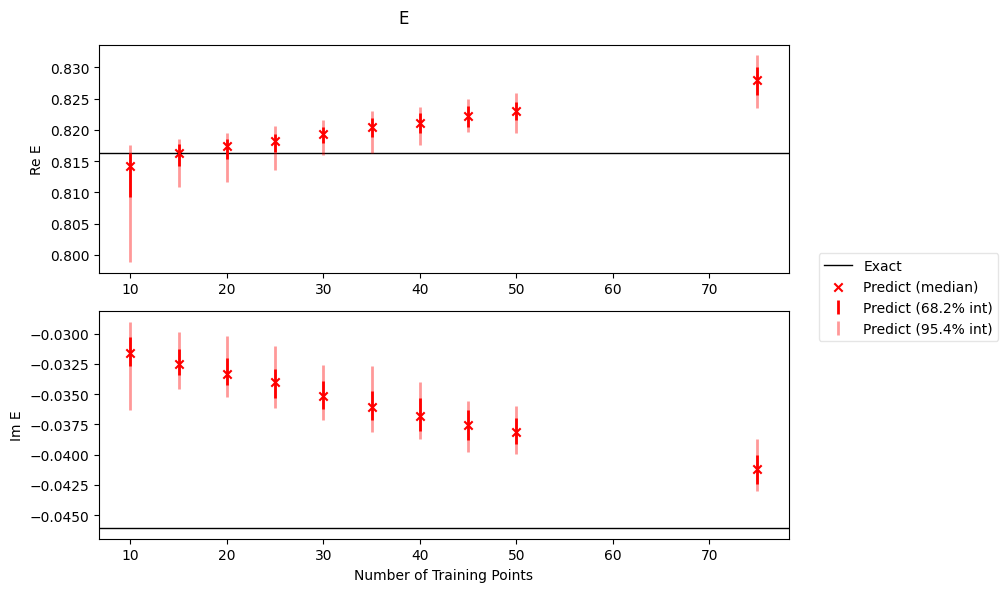

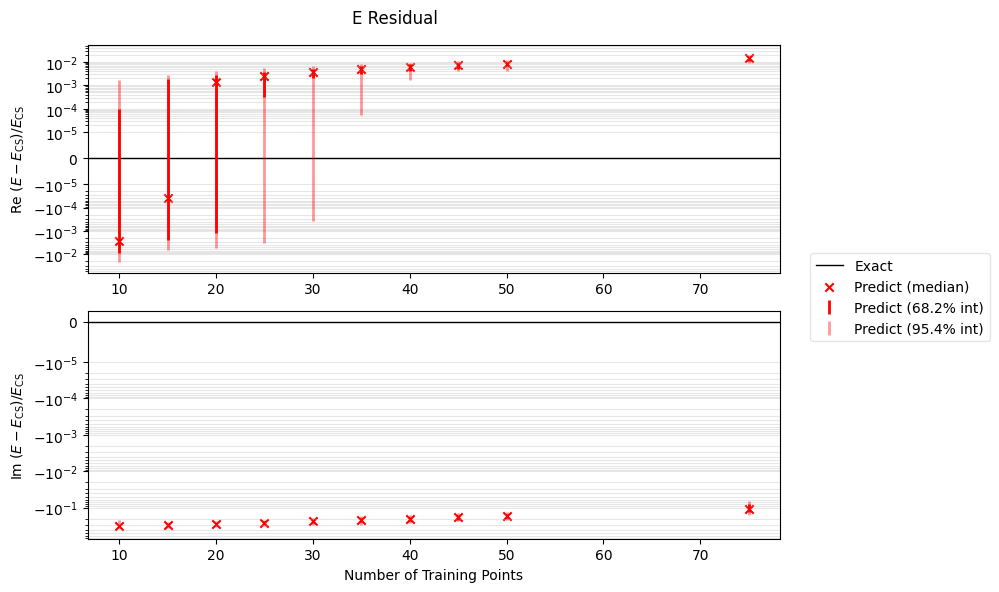

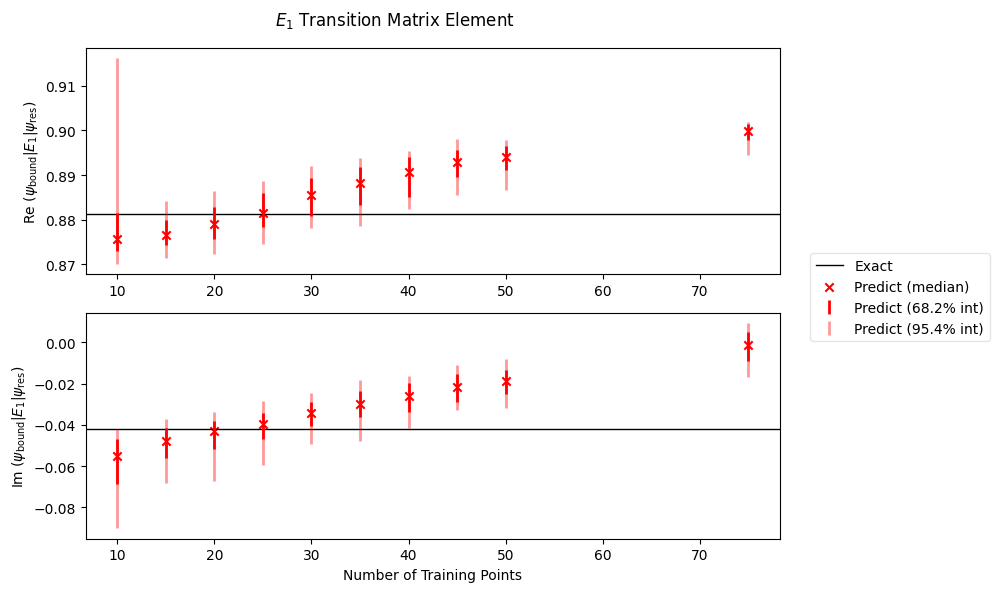

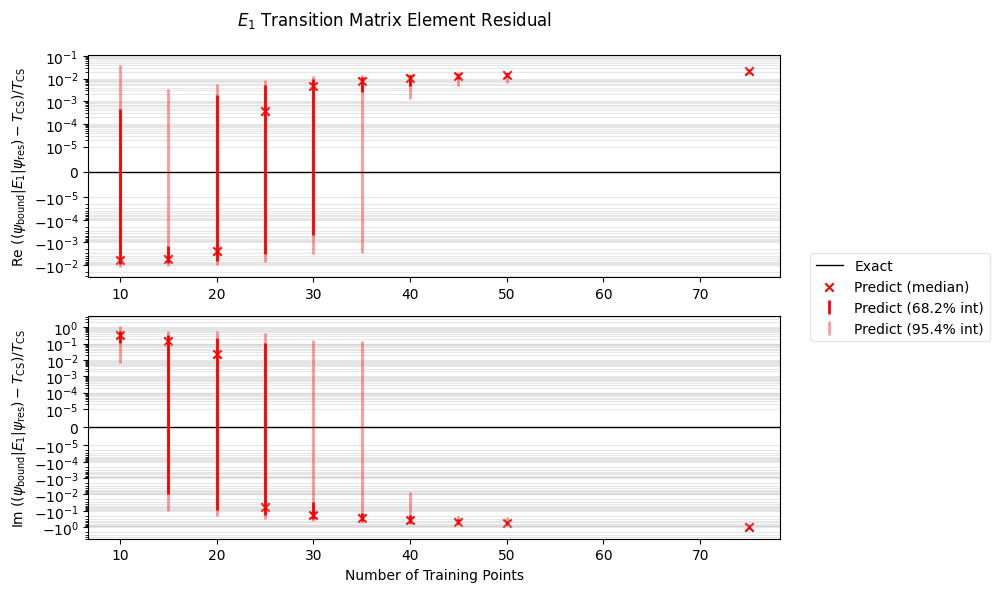

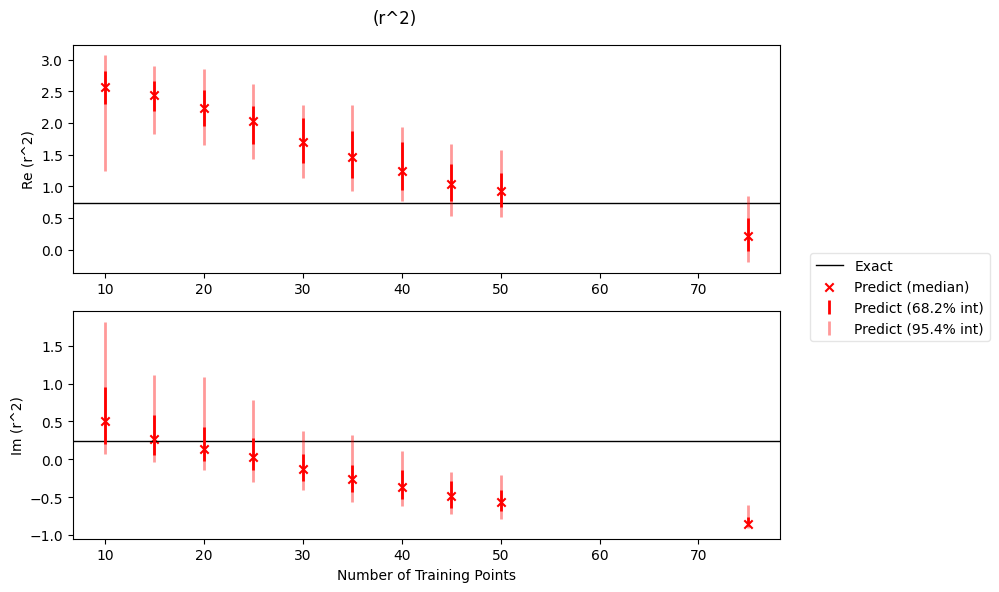

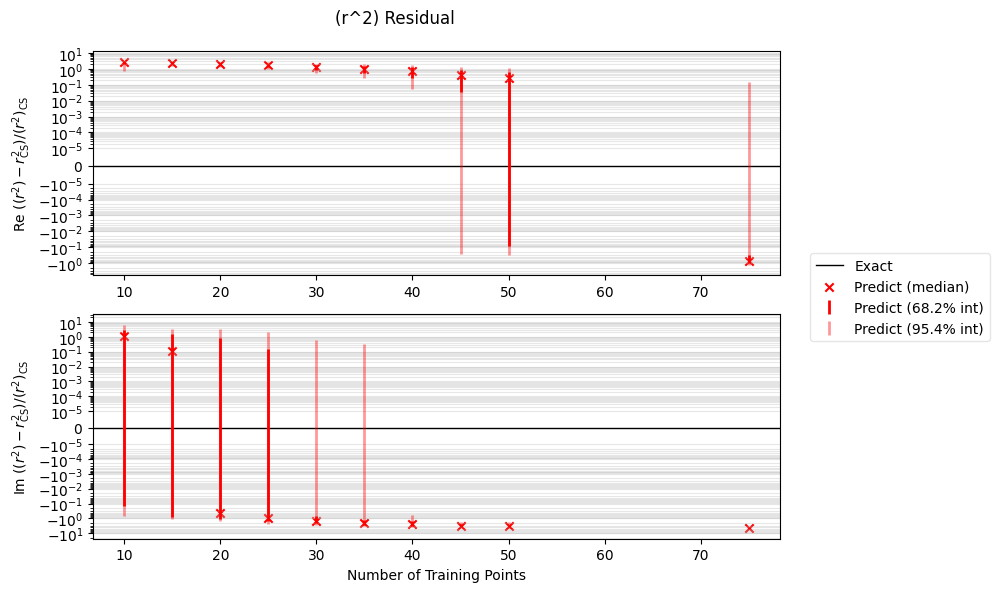

In [29]:
import matplotlib.ticker as mticker
def plot(fig, ax, exact, xs, data, **kwargs):
    axreal, aximag = ax
    # get stats from data
    med, err68, err95 = decompose_stats(data)

    # get plot kwargs
    title = kwargs.get("title", "")
    ylabel = kwargs.get("ylabel", "")
    xlabel = kwargs.get("xlabel", "")
    scale = kwargs.get("scale", "linear")
    cutoff = kwargs.get("cutoff", 0)
    color = kwargs.get("color", "red")

    # plot real and imaginary components
    axreal.axhline(y=np.real(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    aximag.axhline(y=np.imag(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    plot_stats(fig, (axreal, aximag), xs, med, err68, err95, cutoff=cutoff, color=color)

    # set labels, title, and legend
    axreal.set_ylabel(f"Re {ylabel}")
    aximag.set_ylabel(f"Im {ylabel}")
    aximag.set_xlabel(xlabel)
    #axreal.set_xlabel(xlabel)
    if scale=="symlog":
        axreal.set_yscale(scale, linthresh=1e-5)
        aximag.set_yscale(scale, linthresh=1e-5)
        for ax in (axreal, aximag):
            ax.yaxis.set_major_locator(mticker.SymmetricalLogLocator(base=10, linthresh=1e-5))
            ax.yaxis.set_minor_locator(mticker.SymmetricalLogLocator(base=10, linthresh=1e-5,
                                                                      subs=np.arange(2, 10)))
            ax.grid(True, which='both', axis='y', alpha=0.3)
    else:
        axreal.set_yscale(scale)
        aximag.set_yscale(scale)
    fig.suptitle(f"{title}")

    handles, labels = axreal.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), framealpha=0.5)
    axreal.legend().remove()
    aximag.legend().remove()
    return fig, (axreal, aximag)
    
# Plot energy and energy residuals
figsize=(8, 6)
cutoff=2
fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": "E", "xlabel": r"Number of Training Points", "title": "E", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_res, num_phi_points_list, all_energy_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / f"system{system_num}_ec_backrotated_E_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(E - E_\text{CS})/E_\text{CS}$", "cutoff": cutoff, "xlabel": r"Number of Training Points", "title": "E Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_energy_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / f"system{system_num}_ec_backrotated_Eresid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(\psi_\text{bound}|E_1|\psi_\text{res})$", "xlabel": 
               r"Number of Training Points", "cutoff": cutoff, "title": r"$E_1$ Transition Matrix Element"}
_ = plot(fig, (axreal, aximag), real_telem, num_phi_points_list, all_telems_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / f"system{system_num}_ec_backrotated_telem_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$((\psi_\text{bound}|E_1|\psi_\text{res})-T_\text{CS})/T_\text{CS}$", "cutoff": cutoff,
               "xlabel": r"Number of Training Points", "title": r"$E_1$ Transition Matrix Element Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_telems_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / f"system{system_num}_ec_backrotated_telem_resid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"(r^2)", "xlabel": r"Number of Training Points", "title": "(r^2)", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_rr, num_phi_points_list, all_rr_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / f"system{system_num}_ec_backrotated_rr_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$((r^2) - r^2_\text{CS})/(r^2)_\text{CS}$", "cutoff": cutoff, "xlabel": r"Number of Training Points", "title": r"(r^2) Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_rr_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / f"system{system_num}_ec_backrotated_rr_resid_wrt_trainingpoints.png")
plt.show()